In [21]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import pandas as pd

# Load Dataset


In [22]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print("Train samples:", x_train.shape)
print("Test samples:", x_test.shape)

Train samples: (60000, 28, 28)
Test samples: (10000, 28, 28)


# Preprocessing


In [23]:
x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)

print(x_train.shape)

(60000, 784)


# MODEL 1 -> ReLU


In [24]:
model_relu = models.Sequential(
    [
        layers.Dense(128, activation="relu", input_shape=(784,)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(10, activation="softmax"),
    ]
)

model_relu.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

history_relu = model_relu.fit(
    x_train, y_train, epochs=10, validation_split=0.2, batch_size=32
)

c:\Users\besho\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7864 - loss: 0.6001 - val_accuracy: 0.8353 - val_loss: 0.4521
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8468 - loss: 0.4267 - val_accuracy: 0.8540 - val_loss: 0.4016
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8631 - loss: 0.3809 - val_accuracy: 0.8677 - val_loss: 0.3674
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8716 - loss: 0.3547 - val_accuracy: 0.8673 - val_loss: 0.3604
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8773 - loss: 0.3361 - val_accuracy: 0.8656 - val_loss: 0.3661
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8832 - loss: 0.3196 - val_accuracy: 0.8752 - val_loss: 0.3433
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8871 - loss: 0.3070 - val_accuracy: 0.8787 - val_loss: 0.3588
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8918 - loss: 0.2938 - 

# MODEL 2 -> tanh


In [25]:
model_tanh = models.Sequential(
    [
        layers.Dense(128, activation="tanh", input_shape=(784,)),
        layers.Dense(64, activation="tanh"),
        layers.Dropout(0.3),
        layers.Dense(10, activation="softmax"),
    ]
)

model_tanh.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

history_tanh = model_tanh.fit(
    x_train, y_train, epochs=10, validation_split=0.2, batch_size=32
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8060 - loss: 0.5450 - val_accuracy: 0.8462 - val_loss: 0.4251
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8500 - loss: 0.4195 - val_accuracy: 0.8672 - val_loss: 0.3707
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8630 - loss: 0.3796 - val_accuracy: 0.8567 - val_loss: 0.3867
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8725 - loss: 0.3550 - val_accuracy: 0.8741 - val_loss: 0.3540
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8793 - loss: 0.3351 - val_accuracy: 0.8755 - val_loss: 0.3418
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8822 - loss: 0.3218 - val_accuracy: 0.8737 - val_loss: 0.3490
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8867 - loss: 0.3113 - val_accuracy: 0.8778 - val_loss: 0.3452
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8914 - loss: 0.3010 - 

# Evaluate Models


In [26]:
relu_loss, relu_acc = model_relu.evaluate(x_test, y_test)
tanh_loss, tanh_acc = model_tanh.evaluate(x_test, y_test)

print("\nReLU Accuracy:", relu_acc)
print("ReLU Loss:", relu_loss)

print("\ntanh Accuracy:", tanh_acc)
print("tanh Loss:", tanh_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8801 - loss: 0.3481
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8761 - loss: 0.3412

ReLU Accuracy: 0.8801000118255615
ReLU Loss: 0.34806954860687256

tanh Accuracy: 0.8761000037193298
tanh Loss: 0.3411653935909271


# Comparison table


In [27]:
import pandas as pd

# Create comparison table

results = pd.DataFrame(
    {
        "Model": ["ReLU", "tanh"],
        "Accuracy": [relu_acc, tanh_acc],
        "Loss": [relu_loss, tanh_loss],
    }
)

print(results.to_string(index=False))

Model  Accuracy     Loss
 ReLU    0.8801 0.348070
 tanh    0.8761 0.341165


# Compare LOSS


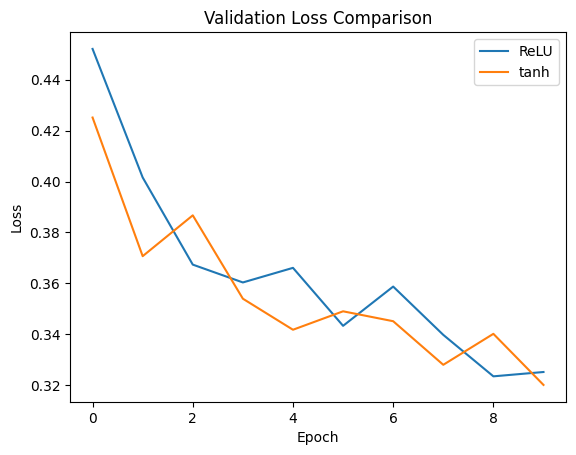

In [28]:
plt.plot(history_relu.history["val_loss"])
plt.plot(history_tanh.history["val_loss"])

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["ReLU", "tanh"])

plt.show()

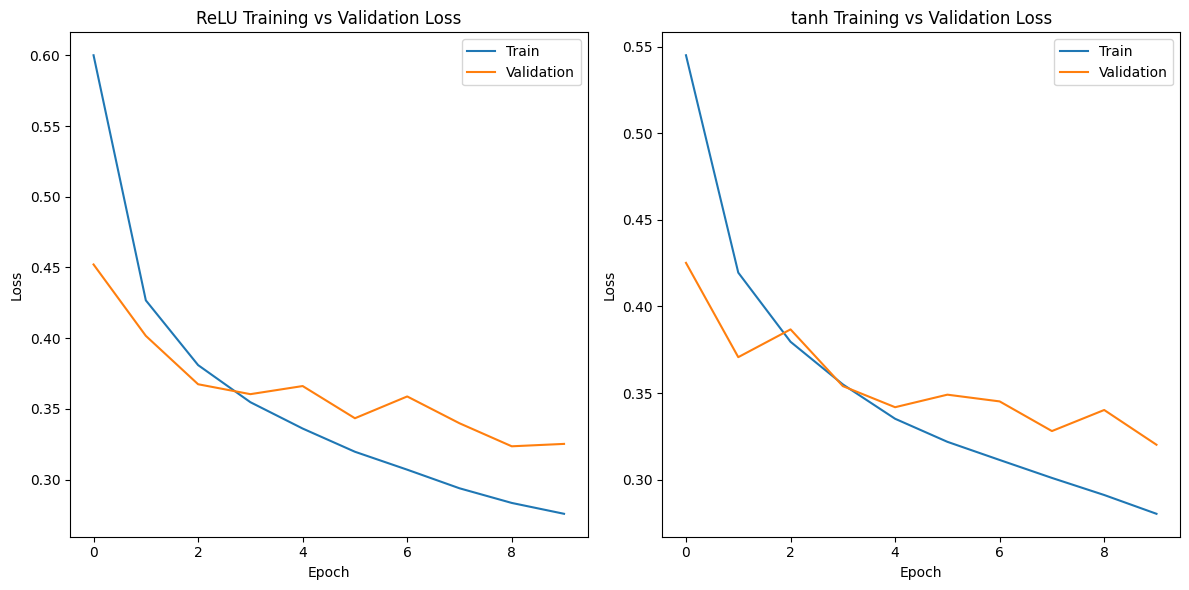

In [37]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history_relu.history["loss"])
plt.plot(history_relu.history["val_loss"])
plt.title("ReLU Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])

plt.subplot(1, 2, 2)
plt.plot(history_tanh.history["loss"])
plt.plot(history_tanh.history["val_loss"])
plt.title("tanh Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])

plt.tight_layout()
plt.show()

# Compare ACCURACY


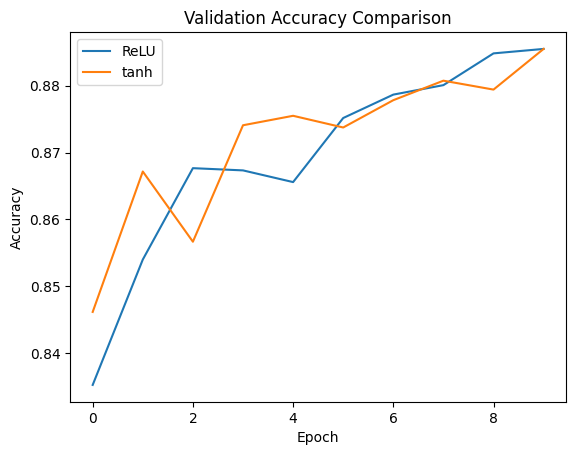

In [29]:
plt.plot(history_relu.history["val_accuracy"])
plt.plot(history_tanh.history["val_accuracy"])

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["ReLU", "tanh"])

plt.show()

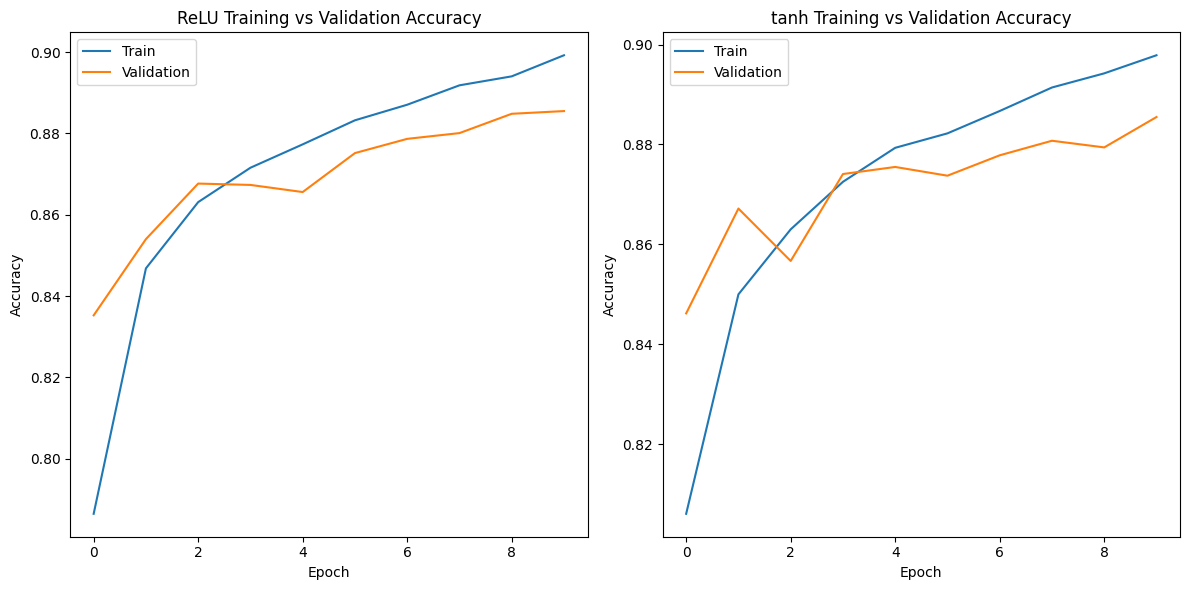

In [36]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history_relu.history["accuracy"])
plt.plot(history_relu.history["val_accuracy"])
plt.title("ReLU Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

plt.subplot(1, 2, 2)
plt.plot(history_tanh.history["accuracy"])
plt.plot(history_tanh.history["val_accuracy"])
plt.title("tanh Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

plt.tight_layout()
plt.show()